In [1]:
import torch
import matplotlib.pyplot as plt

from src.manifolds.euclidean.pullback.deformed_gaussian.quadratic_unbend_pullback import QuadraticUnbendPullbackEuclidean
from src.riemannian_autoencoder.deformed_gaussian_riemannian_autoencoder import DeformedGaussianRiemannianAutoencoder

/Users/wdiepeveen/Documents/Postdoc/projects/4 - score-based Riemannian geometry from corrupted data/src/Score-based-Riemannian-geometry-from-corrupted-data/.venv/lib/python3.8/site-packages/torch/functional.py:507: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:3550.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


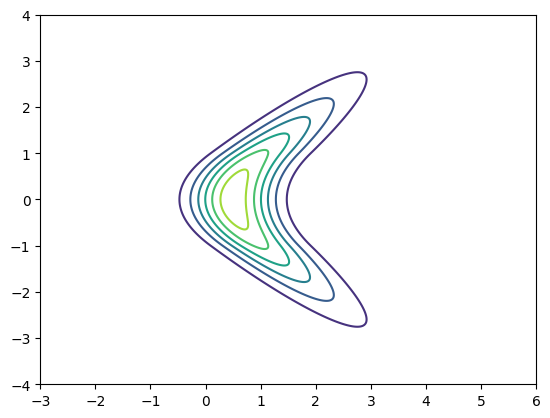

In [2]:
manifold = QuadraticUnbendPullbackEuclidean()

xx = torch.linspace(-3.0, 6.0, 500)
yy = torch.linspace(-4.0, 4.0, 500)
x_grid, y_grid = torch.meshgrid(xx, yy)

xy_grid = torch.zeros((*x_grid.shape,2))
xy_grid[:,:,0] = x_grid
xy_grid[:,:,1] = y_grid

density = torch.exp(manifold.dg.log_density(xy_grid.reshape(-1,2)).reshape(x_grid.shape))
plt.contour(x_grid, y_grid, density)
plt.savefig("results/toy/quadratic_unbend_pullback/density.eps")
plt.show()

In [3]:
# special points
x0 = torch.tensor([3.,3.])
x1 = torch.tensor([3.,-3.])

In [4]:
# test inner
X = torch.eye(2)

inner_0 = manifold.inner(torch.zeros(2)[None], X[None], X[None])
inner_x0 = manifold.inner(x0[None], X[None], X[None])

print(inner_0)
print(inner_x0)

tensor([[[16.0000,  0.0000],
         [ 0.0000,  0.1250]]])
tensor([[[ 16.0000, -16.0000],
         [-16.0000,  16.1250]]])


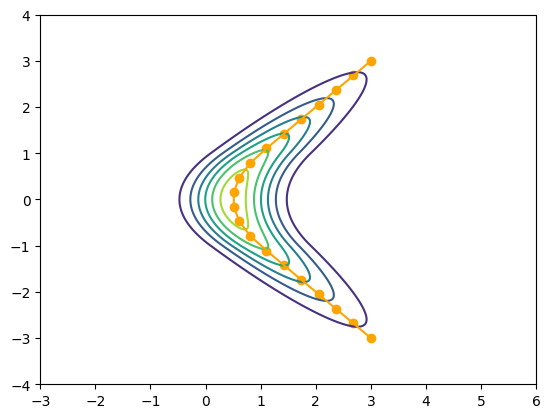

In [5]:
# test interpolation
t = torch.linspace(0.,1.,20)

geodesic_x0_x1 = manifold.geodesic(x0,x1,t).detach().numpy()

plt.contour(x_grid, y_grid, density)
plt.plot(geodesic_x0_x1[:,0], geodesic_x0_x1[:,1], color="orange")
plt.scatter(geodesic_x0_x1[:,0], geodesic_x0_x1[:,1], color="orange")
plt.savefig("results/toy/quadratic_unbend_pullback/geodesic.eps")
plt.show()

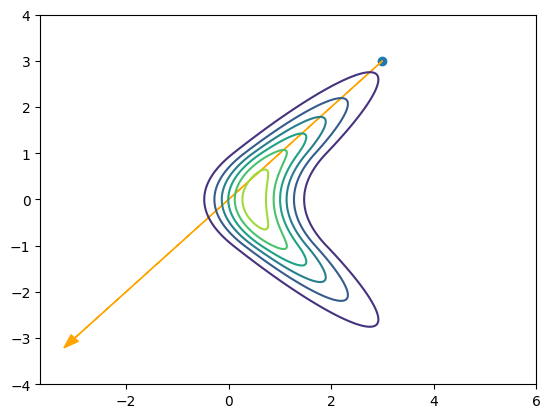

In [6]:
# test logarithmic mapping
logarithmic_x0_x1 = manifold.log(x0,x1[None])[0].detach().numpy()

plt.contour(x_grid, y_grid, density)
plt.scatter(x0[0], x0[1])
plt.arrow(x0[0], x0[1], logarithmic_x0_x1[0], logarithmic_x0_x1[1], head_width=0.2, color="orange")
plt.savefig("results/toy/quadratic_unbend_pullback/logarithmic.eps")
plt.show()

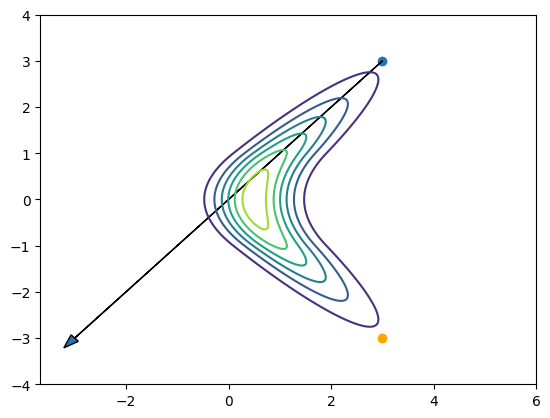

The error between exp_x0(log_x0 (x1)) and x1 is 3.3717478231665154e-07


In [7]:
# test exponential mapping

exponential_to_x1 = manifold.exp(x0,torch.tensor(logarithmic_x0_x1)[None])[0].detach().numpy()

plt.contour(x_grid, y_grid, density)
plt.scatter(x0[0], x0[1])
plt.arrow(x0[0], x0[1], logarithmic_x0_x1[0], logarithmic_x0_x1[1], head_width=0.2)
plt.scatter(exponential_to_x1[0], exponential_to_x1[1], color="orange")
plt.savefig("results/toy/quadratic_unbend_pullback/exponential.eps")
plt.show()
print(f"The error between exp_x0(log_x0 (x1)) and x1 is {torch.norm(torch.tensor(exponential_to_x1) - x1)}")

In [8]:
# test distance
l2_distance = torch.norm(x0 - x1)
distance = manifold.distance(x0[None,None], x1[None,None])[0,0,0]
print(l2_distance)
print(distance)

tensor(6.)
tensor(2.1213)


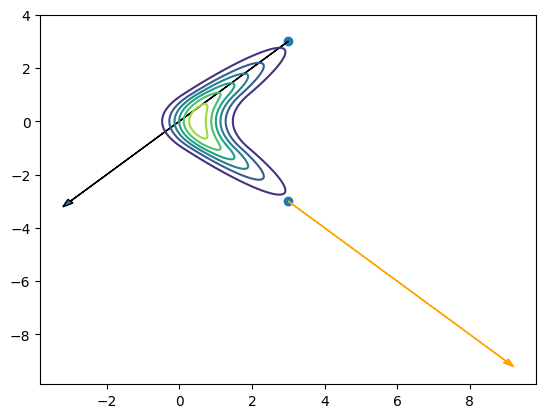

In [9]:
# test parallel transport
parallel_transport = manifold.parallel_transport(x0, torch.tensor(logarithmic_x0_x1)[None], x1)[0]

plt.contour(x_grid, y_grid, density)
plt.scatter(torch.tensor([x0[0], x1[0]]), torch.tensor([x0[1], x1[1]]))
plt.arrow(x0[0], x0[1], logarithmic_x0_x1[0], logarithmic_x0_x1[1], head_width=0.2)
plt.arrow(x1[0], x1[1], parallel_transport[0], parallel_transport[1], head_width=0.2, color="orange")
plt.savefig("results/toy/quadratic_unbend_pullback/parallel-transport.eps")
plt.show()


sorted_diagonal: tensor([4.0000, 0.2500])
constructed a Riemannian autoencoder with d_eps = 1 and eps = 0.05882352963089943


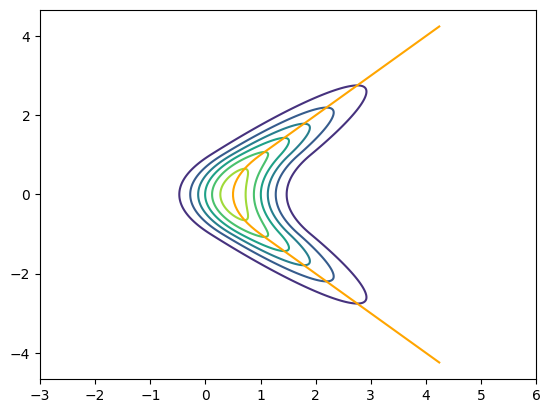

In [14]:
# Riemannian autoencoder
epsilon = 0.1
banana_rae = DeformedGaussianRiemannianAutoencoder(manifold, epsilon)

p = torch.linspace(-6, 6, 100)[:,None]
rae_decode_p = banana_rae.decode(p)

plt.contour(x_grid, y_grid, density)
plt.plot(rae_decode_p[:,0], rae_decode_p[:,1], color="orange")
plt.savefig("results/toy/quadratic_banana_pullback/rae_manifold.eps")
plt.show()